In [73]:
# Import des utilitaires

## librairies de traitement de données
import pandas as pd

## librairies de gestion de fichiers
import os

## librairies de visualisation des valeurs manquantes
import missingno as msno

In [74]:
# Fonctions pour importer tout type de fichier en determinant le type de fichier et son delimiter

##Fonction pour récupérer le séparateur
def separateurDetect(fichier):

    with open(fichier, mode= "r") as f: #encoding= encodage
        premieres_lignes = f.readline(15)
    for sep in [',', ';', "\t", ':', '|']:
        if sep in premieres_lignes:
            return sep
    return ',' # Par défaut

#Fonction pour importer un fichier
def importFichier(fichier):

    # Le fichier existe ?
    if not os.path.exists(fichier):
        raise FileExistsError(f"Le fichier {fichier} est introuvable.")
    
    # Détecton le type du fichier
    extension = os.path.splitext(fichier)[1].lower()

    if extension in ['.csv', '.tsv', '.txt']:
        # Détection du séparateur
        separateur = separateurDetect(fichier)
        print(f"Chargement d'un fichier avec pour séparateur '{separateur}'.")
        return pd.read_csv(fichier, sep= separateur)
    
    elif extension in ['.xls', '.xslx']:
        print(f"Chargement d'un fichier Excel .")#
        return pd.read_excel(fichier, engine= 'openpyxl')
    
    else:
        raise ValueError(f"Format de fichier non pris en compte : {extension}")


In [75]:
# Fonctions pour analyser les données

## Fonction pour catégoriser les variables
def categoriseVariables(df):
    
    info_type = df.dtypes
    variable_qualitative = []
    variable_quantitative = []

    for index in info_type.index:
        if (info_type[index] == 'float') | (info_type[index] == 'int'):
            variable_quantitative.append(index)
        else:
            variable_qualitative.append(index)
    return variable_qualitative, variable_quantitative

## Fonction pour décrire une dataframe 
def infoData(df):
    info = df.info().pd.DataFrame()
    return info

def descriptionData(df):
    nb_lignes, nb_col = df.shape
    print(f"La dataframe contient {nb_lignes} lignes et {nb_col} colonnes.")

## Fonction pour afficher les afficher les colonnes ayant un taux de remplissage inférieur à un seuil
def colManquantes(df, seuil):
    # Calculer le taux de remplissage 
    taux_remplissage = df.notnull().mean() * 100
    # Sélection des colonnes avec un taux de remplissage < seuil
    colonnes = taux_remplissage[taux_remplissage < seuil].index.tolist()
    print(f"nombre de colonnes avec un taux de remplissage inférieur à {seuil}% : {len(colonnes)}")
    return colonnes

## Fonction pour supprimer des colonnes dans une dataframe
def supprimeCol(df, colonnes):
    return df.drop(columns = colonnes)

## Fonction pour selectionner des colonnes dans une dataframe
def colSelection(df, colonnes):
    return df[colonnes]

In [76]:
# Fonctions pour visualiser les données

## Fonction pour visualiser les valeurs manquantes
def visuelDonneesNa(df):
    msno.bar(df,  color= 'dodgerblue')

In [77]:
#Importation du fichier
fichier = importFichier("2016_Building_Energy_Benchmarking.csv")
fichier.head()

Chargement d'un fichier avec pour séparateur ','.


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [78]:
descriptionData(fichier)

La dataframe contient 3376 lignes et 46 colonnes.


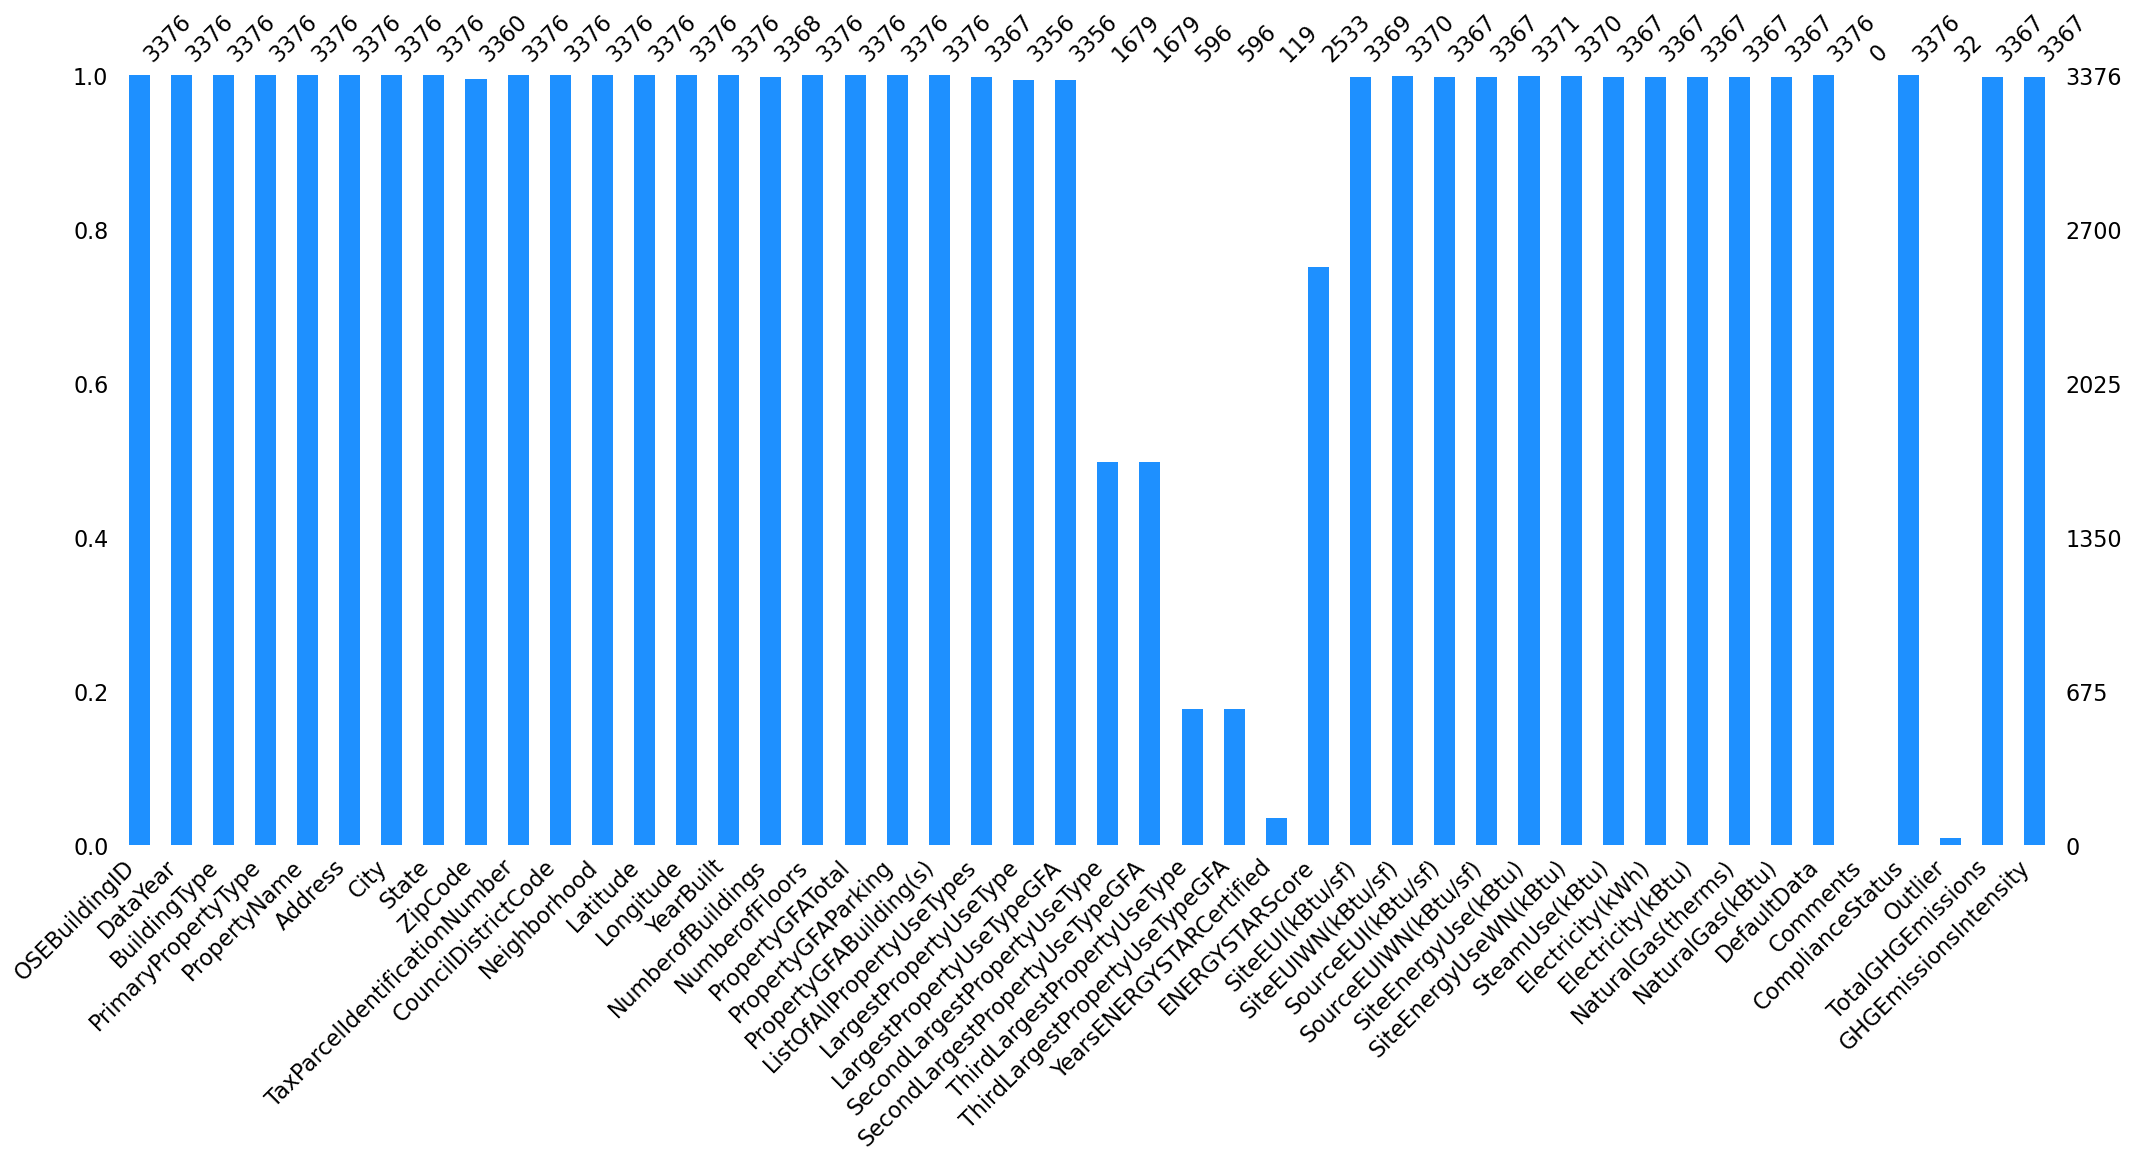

In [79]:
#Visualisation des valeurs manquantes
visuelDonneesNa(fichier)

In [80]:
# Sélection des colonnes avec un taux de remplissage < 50%
col_na = colManquantes(fichier, 50)
col_na

nombre de colonnes avec un taux de remplissage inférieur à 50% : 7


['SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'YearsENERGYSTARCertified',
 'Comments',
 'Outlier']

In [81]:
# Suppression des colonnes avec un taux de remplissage < 50%
fichier_col_supp_50 = supprimeCol(fichier, col_na)
fichier_col_supp_50.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,Compliant,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,Compliant,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,Compliant,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,Compliant,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,Compliant,505.01,2.88


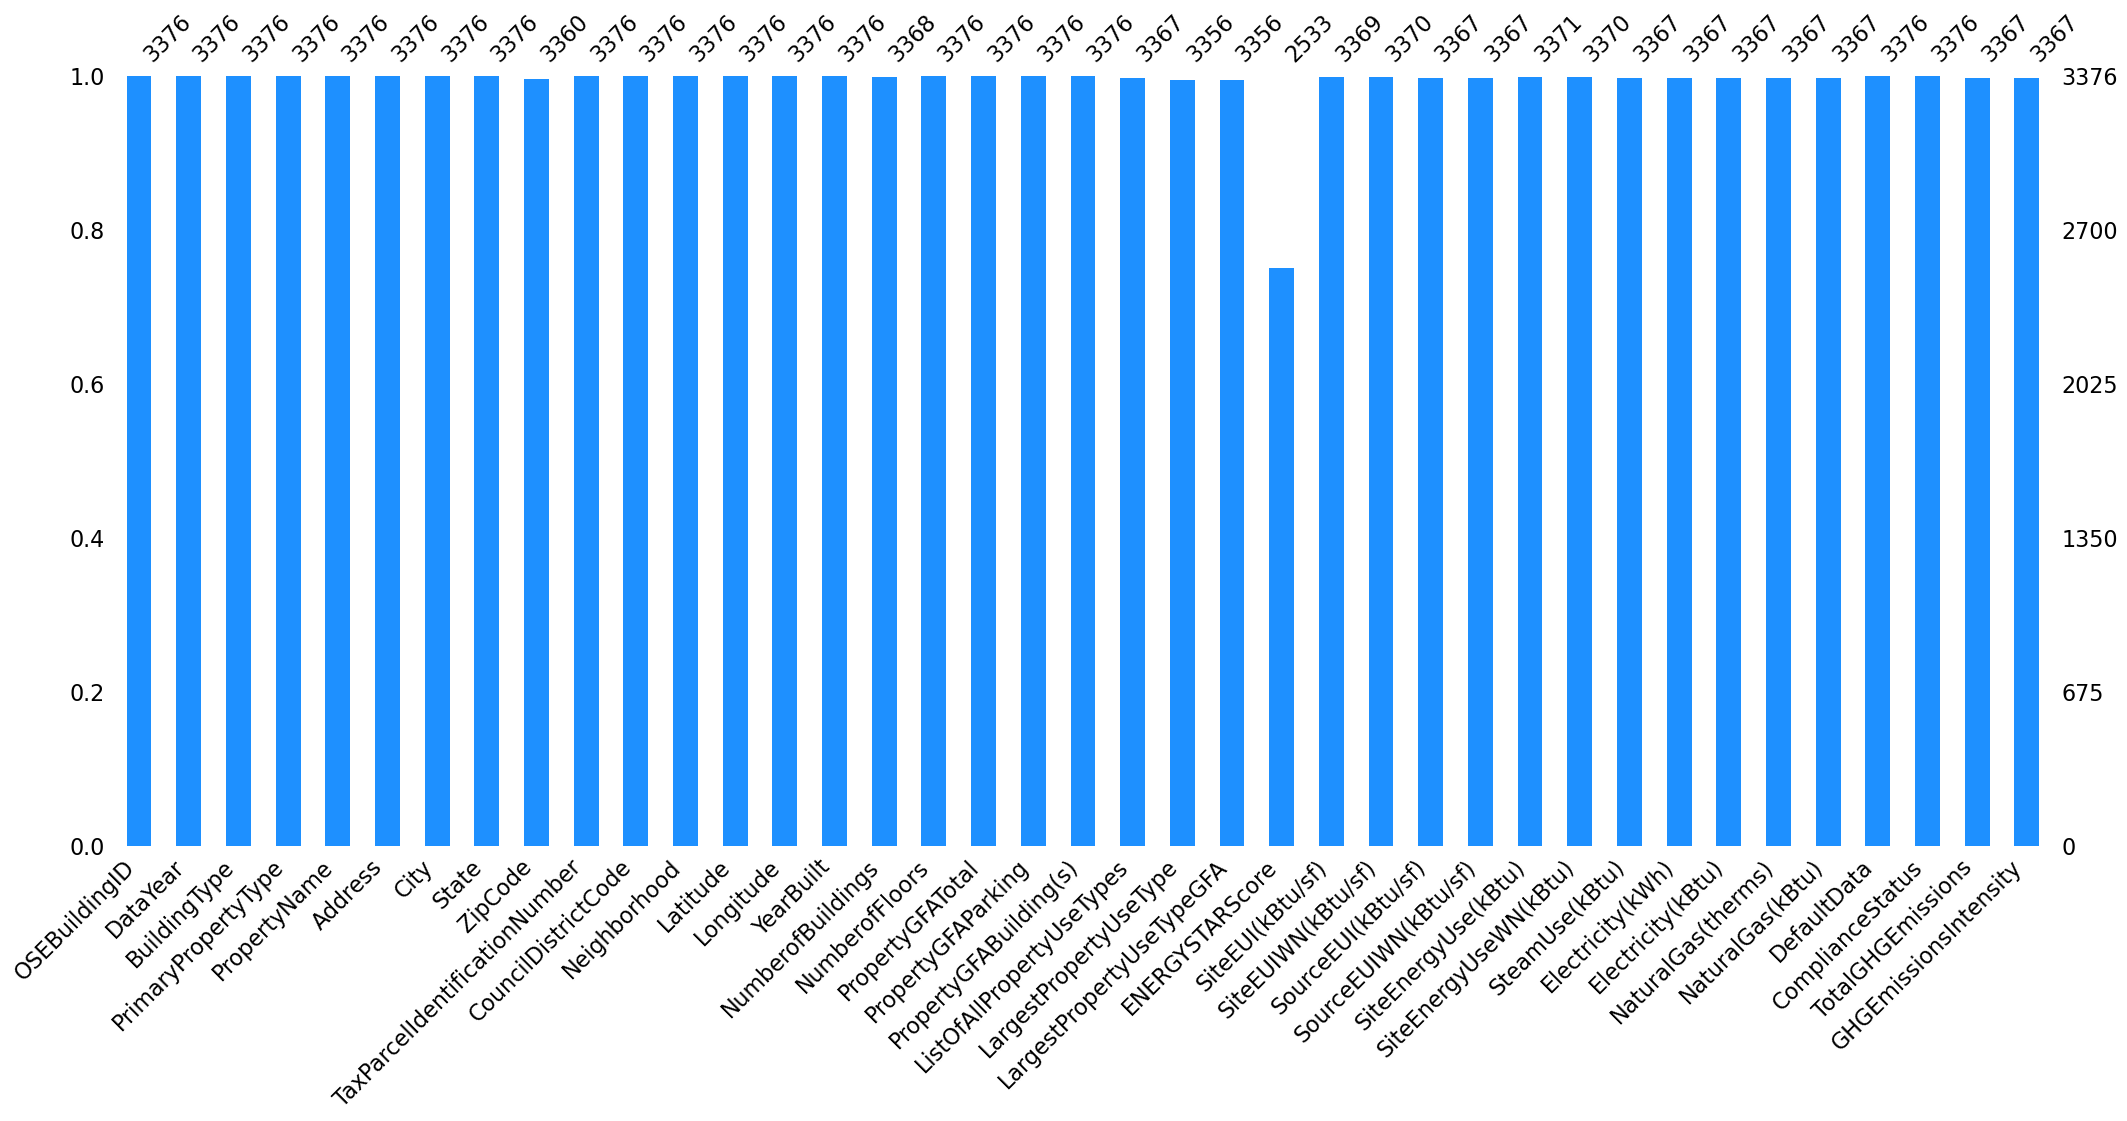

In [82]:
# visuel du taux de remplissage
visuelDonneesNa(fichier_col_supp_50)

In [83]:
# Premier choix et description des varialbes
# Liste des noms des colonnes sélectionnées
variables_list = ['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors',
                  'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 
                  'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 
                  'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'GHGEmissionsIntensity', 
                  'ENERGYSTARScore']

# Liste des descriptions correspondantes
descriptions = ['ID du bâtiment OSE', 'Type de bâtiment (résidentiel, commercial, etc.)', 'Type de propriété principale', 'Année de construction', 'Nombre de bâtiments', 
                'Nombre d\'étages', 'Surface totale du bâtiment et du parking', 'Surface de stationnement de la propriété', 'Surface du bâtiment de la propriété', 
                'utilisation de l\'énergie du site d\'une propriété divisée par sa superficie brute au sol', 'EUI du site normalisé (énergétique du site que la propriété aurait consommée pendant les conditions météorologiques moyennes de 30 ans)',
                'énergie de source d\'une propriété divisée par sa surface brute au sol', 'EUI de la source normalisé (kBtu/sf)', 
                'Utilisation d\'énergie du site (kBtu)', 'Utilisation d\'énergie du site normalisé (kBtu)', 'La quantité annuelle de vapeur de district consommée par la propriété sur place, mesurée en milliers d\'unités thermiques britanniques (kBtu)', 
                'La quantité annuelle d\'électricité consommée par la propriété', 'La quantité annuelle d\'électricité consommée par la propriété', 'La quantité annuelle de gaz naturel consommée par la propriété (therms)', 'La quantité annuelle de gaz naturel consommée par la propriété (kBtu)', 
                'Intensité des émissions de GES (kgCO2e/ft2)', 'Score ENERGY STAR']

# Création de la DataFrame
df_description = pd.DataFrame({
    'Nom de la colonne': variables_list,
    'Description': descriptions
})

# Ajuster les paramètres d'affichage de pandas pour afficher toutes les colonnes
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)

# Affichage de la DataFrame
df_description

,Nom de la colonne,Description
0,OSEBuildingID,ID du bâtiment OSE
1,BuildingType,"Type de bâtiment (résidentiel, commercial, etc.)"
2,PrimaryPropertyType,Type de propriété principale
3,YearBuilt,Année de construction
4,NumberofBuildings,Nombre de bâtiments
5,NumberofFloors,Nombre d'étages
6,PropertyGFATotal,Surface totale du bâtiment et du parking
7,PropertyGFAParking,Surface de stationnement de la propriété
8,PropertyGFABuilding(s),Surface du bâtiment de la propriété
9,SiteEUI(kBtu/sf),utilisation de l'énergie du site d'une propriété divisée par sa superficie brute au sol


In [84]:
# Sélection des varialbes
data_select = colSelection(fichier_col_supp_50, variables_list)
data_select.head()

,OSEBuildingID,BuildingType,PrimaryPropertyType,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
0,1,NonResidential,Hotel,1927,1.0,12,88434,0,88434,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,2.83,60.0
1,2,NonResidential,Hotel,1996,1.0,11,103566,15064,88502,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,2.86,61.0
2,3,NonResidential,Hotel,1969,1.0,41,956110,196718,759392,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,2.19,43.0
3,5,NonResidential,Hotel,1926,1.0,10,61320,0,61320,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,4.67,56.0
4,8,NonResidential,Hotel,1980,1.0,18,175580,62000,113580,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,2.88,75.0


In [85]:
# Nombre bâtiment par type
data_select["BuildingType"].value_counts()

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [86]:
# Selection des bâtiments contenant le type "NonResidential"
data_select_filtre = data_select[data_select["BuildingType"].str.contains("(?i)NonResidential", na=False)]
data_select_filtre.head()

,OSEBuildingID,BuildingType,PrimaryPropertyType,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
0,1,NonResidential,Hotel,1927,1.0,12,88434,0,88434,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,2.83,60.0
1,2,NonResidential,Hotel,1996,1.0,11,103566,15064,88502,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,2.86,61.0
2,3,NonResidential,Hotel,1969,1.0,41,956110,196718,759392,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,2.19,43.0
3,5,NonResidential,Hotel,1926,1.0,10,61320,0,61320,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,4.67,56.0
4,8,NonResidential,Hotel,1980,1.0,18,175580,62000,113580,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,2.88,75.0


In [87]:
# Nombre bâtiment par type (vérification)
data_select_filtre["BuildingType"].value_counts()

BuildingType
NonResidential        1460
Nonresidential COS      85
Nonresidential WA        1
Name: count, dtype: int64

In [88]:
# Conversion de l'id des batiments et de l'année de conctruction en facteur
data_select_filtre[["OSEBuildingID", "YearBuilt"]] = data_select_filtre[["OSEBuildingID", "YearBuilt"]].astype('category')

/var/folders/h0/8500ftrn70xcn1_yvyhmwns00000gn/T/ipykernel_28356/3836959709.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_select_filtre[["OSEBuildingID", "YearBuilt"]] = data_select_filtre[["OSEBuildingID", "YearBuilt"]].astype('category')


In [89]:
data_select_filtre.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1546 entries, 0 to 3375
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   OSEBuildingID           1546 non-null   category
 1   BuildingType            1546 non-null   object  
 2   PrimaryPropertyType     1546 non-null   object  
 3   YearBuilt               1546 non-null   category
 4   NumberofBuildings       1544 non-null   float64 
 5   NumberofFloors          1546 non-null   int64   
 6   PropertyGFATotal        1546 non-null   int64   
 7   PropertyGFAParking      1546 non-null   int64   
 8   PropertyGFABuilding(s)  1546 non-null   int64   
 9   SiteEUI(kBtu/sf)        1543 non-null   float64 
 10  SiteEUIWN(kBtu/sf)      1543 non-null   float64 
 11  SourceEUI(kBtu/sf)      1544 non-null   float64 
 12  SourceEUIWN(kBtu/sf)    1544 non-null   float64 
 13  SiteEnergyUse(kBtu)     1544 non-null   float64 
 14  SiteEnergyUseWN(kBtu)   1543 

In [90]:
# Catégorisation des variables
quali,quanti = categoriseVariables(data_select_filtre)

In [91]:
# variables qualitatives
quali

['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'YearBuilt']

In [92]:
# variables quantitatives
quanti

['NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'GHGEmissionsIntensity',
 'ENERGYSTARScore']

In [93]:
# verification des doublons
data_select_filtre["OSEBuildingID"].duplicated().sum()

0

In [94]:
# Vérification des valeurs manquantes
data_select_filtre.isnull().sum()

OSEBuildingID               0
BuildingType                0
PrimaryPropertyType         0
YearBuilt                   0
NumberofBuildings           2
NumberofFloors              0
PropertyGFATotal            0
PropertyGFAParking          0
PropertyGFABuilding(s)      0
SiteEUI(kBtu/sf)            3
SiteEUIWN(kBtu/sf)          3
SourceEUI(kBtu/sf)          2
SourceEUIWN(kBtu/sf)        2
SiteEnergyUse(kBtu)         2
SiteEnergyUseWN(kBtu)       3
SteamUse(kBtu)              2
Electricity(kWh)            2
Electricity(kBtu)           2
NaturalGas(therms)          2
NaturalGas(kBtu)            2
GHGEmissionsIntensity       2
ENERGYSTARScore           540
dtype: int64

In [95]:
data_select_filtre.describe()

,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
count,1544.000000,1546.000000,1.546000e+03,1546.000000,1.546000e+03,1543.000000,1543.000000,1544.000000,1544.000000,1.544000e+03,1.543000e+03,1.544000e+03,1.544000e+03,1.544000e+03,1.544000e+03,1.544000e+03,1544.000000,1006.000000
mean,1.036269,4.283959,1.118044e+05,13822.981889,9.798146e+04,74.203953,76.585677,181.615026,183.843588,7.642371e+06,7.749996e+06,4.951487e+05,1.590416e+06,5.426501e+06,1.670065e+04,1.670065e+06,1.607506,63.830020
std,0.569231,6.783014,1.915023e+05,43679.918511,1.682204e+05,75.588468,76.576520,190.144184,190.131202,1.865844e+07,1.882062e+07,5.306124e+06,3.821341e+06,1.303841e+07,5.504752e+04,5.504752e+06,2.245002,28.915866
min,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,0.000000,0.000000,0.000000,-2.100000,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,-0.020000,1.000000
25%,1.000000,1.000000,2.877000e+04,0.000000,2.770000e+04,34.250000,36.099998,78.699997,81.000000,1.204670e+06,1.265929e+06,0.000000e+00,2.077251e+05,7.087580e+05,0.000000e+00,0.000000e+00,0.340000,44.000000
50%,1.000000,2.000000,4.730250e+04,0.000000,4.511350e+04,53.200001,55.799999,137.750000,140.099998,2.609590e+06,2.739359e+06,0.000000e+00,4.788943e+05,1.633988e+06,4.322415e+03,4.322415e+05,0.850000,71.000000
75%,1.000000,4.000000,1.029090e+05,0.000000,9.261400e+04,83.750000,87.400002,210.375004,210.624996,6.968646e+06,7.192840e+06,0.000000e+00,1.469022e+06,5.012304e+06,1.411576e+04,1.411576e+06,1.932500,89.000000
max,9.000000,99.000000,1.952220e+06,512608.000000,1.765970e+06,834.400024,834.400024,2620.000000,2620.000000,2.930908e+08,2.966717e+08,1.349435e+08,8.046087e+07,2.745325e+08,1.381912e+06,1.381912e+08,25.710000,100.000000


In [96]:
# Filtre des valeurs inférieures à 0
## selectionner les colonnes quantitatives
data_quanti = data_select_filtre[quanti]
## Filtrer les lignes où les valeurs des colonnes quantitatives sont inférieures à 0
negative_quanti_val = data_quanti[(data_quanti < 0).any(axis = 1)]
negative_quanti_val

,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
3206,1.0,6,52000,0,52000,7.1,5.0,2.0,-2.1,342726.0938,240132.0938,0.0,-33826.80078,-115417.0,0.0,0.0,-0.02,100.0


In [97]:
# Suppression des valeurs inférieures à 0
data_select_filtre = data_select_filtre.drop(negative_quanti_val.index).reset_index(drop=True)
data_select_filtre.head()

,OSEBuildingID,BuildingType,PrimaryPropertyType,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
0,1,NonResidential,Hotel,1927,1.0,12,88434,0,88434,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,2.83,60.0
1,2,NonResidential,Hotel,1996,1.0,11,103566,15064,88502,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,2.86,61.0
2,3,NonResidential,Hotel,1969,1.0,41,956110,196718,759392,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,2.19,43.0
3,5,NonResidential,Hotel,1926,1.0,10,61320,0,61320,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,4.67,56.0
4,8,NonResidential,Hotel,1980,1.0,18,175580,62000,113580,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,2.88,75.0


In [98]:
# Choix des variables finales
quali = ['OSEBuildingID', 'YearBuilt']
quanti = ['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
         'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'GHGEmissionsIntensity', 'ENERGYSTARScore']

# Dataframe finale
data_final = data_select_filtre[quali + quanti]
data_final.head()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
0,1,1927,1.0,12,88434,0,88434,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,3946027.0,1276453.0,2.83,60.0
1,2,1996,1.0,11,103566,15064,88502,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,3242851.0,5145082.0,2.86,61.0
2,3,1969,1.0,41,956110,196718,759392,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,49526664.0,1493800.0,2.19,43.0
3,5,1926,1.0,10,61320,0,61320,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,2768924.0,1811213.0,4.67,56.0
4,8,1980,1.0,18,175580,62000,113580,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,5368607.0,8803998.0,2.88,75.0


In [99]:
# Description de la dataframe finale
descriptionData(data_final)

La dataframe contient 1545 lignes et 18 colonnes.


In [100]:
# Description des variables finales
data_final_describe = df_description[df_description['Nom de la colonne'].isin(data_final.columns)].reset_index(drop=True)
data_final_describe

,Nom de la colonne,Description
0,OSEBuildingID,ID du bâtiment OSE
1,YearBuilt,Année de construction
2,NumberofBuildings,Nombre de bâtiments
3,NumberofFloors,Nombre d'étages
4,PropertyGFATotal,Surface totale du bâtiment et du parking
5,PropertyGFAParking,Surface de stationnement de la propriété
6,PropertyGFABuilding(s),Surface du bâtiment de la propriété
7,SiteEUI(kBtu/sf),utilisation de l'énergie du site d'une propriété divisée par sa superficie brute au sol
8,SiteEUIWN(kBtu/sf),EUI du site normalisé (énergétique du site que la propriété aurait consommée pendant les conditions météorologiques moyennes de 30 ans)
9,SourceEUI(kBtu/sf),énergie de source d'une propriété divisée par sa surface brute au sol


In [101]:
# selection des valeurs manquantes d'une variable
data_final[data_final["SiteEUI(kBtu/sf)"].isnull()]

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
244,435,1990,1.0,6,1400000,0,1400000,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
513,773,1924,NaN,4,63150,0,63150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1316,26532,1928,NaN,2,20760,0,20760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [102]:
# Suppression des valeurs manquantes
data_final = data_final.dropna().reset_index(drop=True)
data_final.head()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
0,1,1927,1.0,12,88434,0,88434,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,3946027.0,1276453.0,2.83,60.0
1,2,1996,1.0,11,103566,15064,88502,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,3242851.0,5145082.0,2.86,61.0
2,3,1969,1.0,41,956110,196718,759392,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,49526664.0,1493800.0,2.19,43.0
3,5,1926,1.0,10,61320,0,61320,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,2768924.0,1811213.0,4.67,56.0
4,8,1980,1.0,18,175580,62000,113580,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,5368607.0,8803998.0,2.88,75.0


In [106]:
# Détection des valeurs abérrantes
## Methode de l'intervalle interquartile des variables quantitatives
def detectOutlierIqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

outlier = detectOutlierIqr(data_final, "SiteEUI(kBtu/sf)")
outlier

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
11,19,1922,1.0,11,92190,25200,66990,159.500000,165.899994,297.399994,303.899994,10750010.0,11179203.0,4870847.5,3832369.0,2046793.0,5.55,35.0
36,84,1922,1.0,5,217603,0,217603,144.399994,153.699997,235.000000,244.800003,42792072.0,45547252.0,0.0,11824772.0,30967300.0,7.94,54.0
37,85,1970,1.0,2,93397,0,93397,175.600006,181.600006,311.500000,320.000000,16402563.0,16959754.0,0.0,5679498.0,10723064.0,6.52,1.0
55,147,1954,4.0,5,285333,0,285333,225.000000,157.300003,479.500000,251.800003,68090728.0,47602720.0,0.0,35237205.0,32853512.0,6.98,14.0
61,198,1953,6.0,10,879000,0,879000,288.799988,293.200012,578.200012,576.599976,253832464.0,257764208.0,0.0,115641210.0,138191238.0,9.27,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,49775,2011,1.0,1,67263,0,67263,218.500000,226.100006,517.500000,525.599976,14697487.0,15210667.0,0.0,9272449.0,5425036.0,5.24,78.0
979,49780,1975,1.0,7,90679,35120,55559,694.700012,694.700012,2181.300049,2181.300049,41680640.0,41680640.0,0.0,41680634.0,0.0,3.20,100.0
986,49940,1920,1.0,8,374466,0,374466,162.300003,165.500000,367.899994,369.399994,163945984.0,167207104.0,73885472.0,90060497.0,0.0,16.91,74.0
987,49946,2010,1.0,8,41198,0,41198,188.600006,189.000000,560.799988,561.299988,7768057.5,7785876.5,0.0,7151865.0,616192.0,2.00,44.0


In [104]:
data_final.isnull().sum()

OSEBuildingID             0
YearBuilt                 0
NumberofBuildings         0
NumberofFloors            0
PropertyGFATotal          0
PropertyGFAParking        0
PropertyGFABuilding(s)    0
SiteEUI(kBtu/sf)          0
SiteEUIWN(kBtu/sf)        0
SourceEUI(kBtu/sf)        0
SourceEUIWN(kBtu/sf)      0
SiteEnergyUse(kBtu)       0
SiteEnergyUseWN(kBtu)     0
SteamUse(kBtu)            0
Electricity(kBtu)         0
NaturalGas(kBtu)          0
GHGEmissionsIntensity     0
ENERGYSTARScore           0
dtype: int64